In [ ]:
pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
from IPython.core import application
!pip install mp-api

In [ ]:
from mp_api.client import MPRester

In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [ ]:
def predict_crystal(a, b, c, alpha, beta, gamma):

    # Put the user's input into a table
    input_data = pd.DataFrame(
        [[a, b, c, alpha, beta, gamma]],
        columns=['a', 'b', 'c', 'alpha', 'beta', 'gamma']
    )

    # Scale the input like the training data
    input_scaled = scaler.transform(input_data)

    # Ask the trained ML model for prediction
    prediction = model.predict(input_scaled)[0]

    # Get prediction confidence
    probabilities = model.predict_proba(input_scaled)[0]
    confidence = max(probabilities) * 100

    return prediction, f"{confidence:.2f}%"

In [ ]:
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("# 🔬 Crystal Structure Classification System")
    gr.Markdown("### AI & Machine Learning Based Crystal Prediction")

    gr.Markdown(
        "Enter the crystal lattice parameters and angles, then click Predict."
    )

    with gr.Row():

        with gr.Column():
            a_input = gr.Number(label="Lattice Parameter a")
            b_input = gr.Number(label="Lattice Parameter b")
            c_input = gr.Number(label="Lattice Parameter c")

        with gr.Column():
            alpha_input = gr.Number(label="Alpha Angle (α)")
            beta_input = gr.Number(label="Beta Angle (β)")
            gamma_input = gr.Number(label="Gamma Angle (γ)")

    predict_button = gr.Button(
        "🔮 Predict Crystal Structure",
        variant="primary"
    )

    prediction_output = gr.Textbox(
        label="🤖 Predicted Crystal Structure"
    )

    confidence_output = gr.Textbox(
        label="📊 Model Confidence"
    )
    visual_output = gr.Plot(
    label="🔷 3D Crystal Visualization"
)

    predict_button.click(
        fn=predict_crystal,
        inputs=[
            a_input,
            b_input,
            c_input,
            alpha_input,
            beta_input,
            gamma_input
        ],
        outputs=[
    prediction_output,
    confidence_output,
    visual_output
]
    )

/tmp/ipykernel_1587/266704193.py:1: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


In [ ]:
API_KEY = "7GWg6B4yAYlF7tHINmLtXxpqRq2fWh3n"

In [ ]:
data_list = []

with MPRester(API_KEY) as mpr:
    materials = mpr.materials.summary.search(
        num_elements=(1, 3),
        fields=["material_id", "structure", "symmetry"],
        chunk_size=50,
        num_chunks=1
    )

    print("Fetching materials...")

    for mat in materials[:100]:
        try:
            structure = mat.structure

            if structure is None:
                continue

            lattice = structure.lattice
            symmetry = mat.symmetry

            if lattice and symmetry:
                data_list.append({
                    "a": lattice.a,
                    "b": lattice.b,
                    "c": lattice.c,
                    "alpha": lattice.alpha,
                    "beta": lattice.beta,
                    "gamma": lattice.gamma,
                    "structure": symmetry.crystal_system
                })

        except Exception as e:
            continue

df = pd.DataFrame(data_list)

print("Dataset shape:", df.shape)
print(df.head())

Retrieving SummaryDoc documents:   0%|          | 0/50 [00:00<?, ?it/s]

Fetching materials...
Dataset shape: (50, 7)
          a         b          c      alpha        beta       gamma  structure
0  4.027830  4.027829   4.027830  59.999995   60.000001   59.999995      Cubic
1  4.046041  4.046041  13.017036  90.000000   90.000000  120.000008  Hexagonal
2  4.002656  4.002656   9.803856  90.000000   90.000000  120.000003   Trigonal
3  4.046863  4.046863  10.064235  78.401536  101.598467  119.999995   Trigonal
4  5.380750  5.380750   5.380750  60.000000   60.000000   60.000000      Cubic


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Input features
X = df[['a', 'b', 'c', 'alpha', 'beta', 'gamma']]

# Target column - convert CrystalSystem objects to strings
y = df['structure'].astype(str)

# Encode crystal structure names
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Scale input data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_scaled, y_encoded)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [ ]:
!pip install plotly -q

In [ ]:
import plotly.graph_objects as go
import numpy as np

In [ ]:
def determine_crystal_system(a, b, c, alpha, beta, gamma):

    # Tolerance for decimal values
    tol = 0.01
    angle_tol = 1.0

    def equal(x, y):
        return abs(x - y) < tol

    def angle_equal(x, y):
        return abs(x - y) < angle_tol

    def is_90(x):
        return angle_equal(x, 90)

    # -------------------------
    # CUBIC
    # a = b = c
    # α = β = γ = 90
    # -------------------------
    if (
        equal(a, b) and equal(b, c)
        and is_90(alpha)
        and is_90(beta)
        and is_90(gamma)
    ):
        return "Cubic"

    # -------------------------
    # TETRAGONAL
    # a = b ≠ c
    # α = β = γ = 90
    # -------------------------
    elif (
        equal(a, b)
        and not equal(b, c)
        and is_90(alpha)
        and is_90(beta)
        and is_90(gamma)
    ):
        return "Tetragonal"

    # -------------------------
    # ORTHORHOMBIC
    # a ≠ b ≠ c
    # α = β = γ = 90
    # -------------------------
    elif (
        not equal(a, b)
        and not equal(b, c)
        and not equal(a, c)
        and is_90(alpha)
        and is_90(beta)
        and is_90(gamma)
    ):
        return "Orthorhombic"

    # -------------------------
    # HEXAGONAL
    # a = b ≠ c
    # α = β = 90
    # γ = 120
    # -------------------------
    elif (
        equal(a, b)
        and not equal(b, c)
        and is_90(alpha)
        and is_90(beta)
        and angle_equal(gamma, 120)
    ):
        return "Hexagonal"

    # -------------------------
    # TRIGONAL / RHOMBOHEDRAL
    # a = b = c
    # α = β = γ ≠ 90
    # -------------------------
    elif (
        equal(a, b)
        and equal(b, c)
        and angle_equal(alpha, beta)
        and angle_equal(beta, gamma)
        and not is_90(alpha)
    ):
        return "Trigonal"

    # -------------------------
    # MONOCLINIC
    # α = γ = 90
    # β ≠ 90
    # -------------------------
    elif (
        is_90(alpha)
        and is_90(gamma)
        and not is_90(beta)
    ):
        return "Monoclinic"

    # -------------------------
    # TRICLINIC
    # General case
    # -------------------------
    else:
        return "Triclinic"

In [ ]:
test_cases = [
    ("Cubic", 5, 5, 5, 90, 90, 90),

    ("Tetragonal", 5, 5, 8, 90, 90, 90),

    ("Orthorhombic", 4, 5, 7, 90, 90, 90),

    ("Hexagonal", 5, 5, 8, 90, 90, 120),

    ("Trigonal", 5, 5, 5, 75, 75, 75),

    ("Monoclinic", 4, 5, 7, 90, 110, 90),

    ("Triclinic", 4, 5, 7, 80, 100, 110)
]

for name, a, b, c, alpha, beta, gamma in test_cases:

    result = determine_crystal_system(
        a, b, c,
        alpha, beta, gamma
    )

    print(f"Expected: {name} → Detected: {result}")

Expected: Cubic → Detected: Cubic
Expected: Tetragonal → Detected: Tetragonal
Expected: Orthorhombic → Detected: Orthorhombic
Expected: Hexagonal → Detected: Hexagonal
Expected: Trigonal → Detected: Trigonal
Expected: Monoclinic → Detected: Monoclinic
Expected: Triclinic → Detected: Triclinic


In [ ]:
def create_crystal_visual(prediction):

    # Default dimensions
    a, b, c = 1, 1, 1

    # Crystal dimensions
    if prediction == "Cubic":
        a, b, c = 1, 1, 1

    elif prediction == "Tetragonal":
        a, b, c = 1, 1, 1.5

    elif prediction == "Orthorhombic":
        a, b, c = 1, 1.3, 1.7

    elif prediction == "Hexagonal":
        a, b, c = 1, 1, 1.5

    elif prediction == "Monoclinic":
        a, b, c = 1, 1.2, 1.5

    elif prediction == "Triclinic":
        a, b, c = 1, 1.3, 1.6


    # Cube vertices
    vertices = np.array([
        [0, 0, 0],
        [a, 0, 0],
        [a, b, 0],
        [0, b, 0],
        [0, 0, c],
        [a, 0, c],
        [a, b, c],
        [0, b, c]
    ])


    # Faces
    faces = [
        [0, 1, 2, 3],
        [4, 5, 6, 7],
        [0, 1, 5, 4],
        [2, 3, 7, 6],
        [1, 2, 6, 5],
        [0, 3, 7, 4]
    ]


    fig = go.Figure()


    # Add transparent crystal faces
    for face in faces:

        points = vertices[face]

        fig.add_trace(
            go.Mesh3d(
                x=points[:, 0],
                y=points[:, 1],
                z=points[:, 2],

                i=[0, 0],
                j=[1, 2],
                k=[2, 3],

                opacity=0.55,

                color="#00D4FF",

                flatshading=True,

                lighting=dict(
                    ambient=0.4,
                    diffuse=0.8,
                    specular=1,
                    roughness=0.3
                )
            )
        )


    # Add glowing vertices
    fig.add_trace(

        go.Scatter3d(

            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],

            mode="markers",

            marker=dict(
                size=9,
                color="#FF3CAC",
                symbol="circle",
                line=dict(
                    color="white",
                    width=2
                )
            ),

            name="Crystal Atoms"
        )
    )


    # Add center atom
    fig.add_trace(

        go.Scatter3d(

            x=[a / 2],
            y=[b / 2],
            z=[c / 2],

            mode="markers",

            marker=dict(
                size=13,
                color="#6A5CFF"
            ),

            name="Center Atom"
        )
    )


    # Crystal edges
    edges = [

        (0, 1), (1, 2), (2, 3), (3, 0),

        (4, 5), (5, 6), (6, 7), (7, 4),

        (0, 4), (1, 5), (2, 6), (3, 7)
    ]


    for edge in edges:

        p1 = vertices[edge[0]]
        p2 = vertices[edge[1]]

        fig.add_trace(

            go.Scatter3d(

                x=[p1[0], p2[0]],
                y=[p1[1], p2[1]],
                z=[p1[2], p2[2]],

                mode="lines",

                line=dict(
                    color="#FFFFFF",
                    width=5
                ),

                showlegend=False
            )
        )


    # Layout
    fig.update_layout(

        title=dict(
            text=f"✨ Interactive 3D {prediction} Crystal Structure",
            font=dict(
                size=22,
                color="#00D4FF"
            )
        ),

        paper_bgcolor="#050B18",

        plot_bgcolor="#050B18",

        scene=dict(

            bgcolor="#050B18",

            xaxis=dict(
                showbackground=False,
                showgrid=False,
                zeroline=False,
                showticklabels=False
            ),

            yaxis=dict(
                showbackground=False,
                showgrid=False,
                zeroline=False,
                showticklabels=False
            ),

            zaxis=dict(
                showbackground=False,
                showgrid=False,
                zeroline=False,
                showticklabels=False
            ),

            camera=dict(
                eye=dict(
                    x=1.7,
                    y=1.7,
                    z=1.2
                )
            ),

            aspectmode="data"
        ),

        margin=dict(
            l=0,
            r=0,
            b=0,
            t=60
        ),

        height=600,

        legend=dict(
            font=dict(
                color="white"
            ),
            bgcolor="rgba(0,0,0,0.3)"
        )
    )


    return fig

In [ ]:
import plotly.graph_objects as go
import numpy as np

In [ ]:
import plotly.graph_objects as go
import numpy as np


# ==========================================
# CREATE CRYSTAL VISUALIZATION
# ==========================================

def create_crystal_visual(crystal_system):

    crystal_system = str(crystal_system).lower().strip()

    fig = go.Figure()


    # ==========================================
    # HELPER FUNCTION: ADD CRYSTAL EDGES
    # ==========================================

    def add_edges(vertices, edges):

        for edge in edges:

            p1 = vertices[edge[0]]
            p2 = vertices[edge[1]]

            fig.add_trace(go.Scatter3d(

                x=[p1[0], p2[0]],
                y=[p1[1], p2[1]],
                z=[p1[2], p2[2]],

                mode="lines",

                line=dict(
                    color="white",
                    width=6
                ),

                showlegend=False

            ))


    # ==========================================
    # HELPER FUNCTION: ADD VERTEX POINTS
    # ==========================================

    def add_vertices(vertices):

        fig.add_trace(go.Scatter3d(

            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],

            mode="markers",

            marker=dict(
                size=7,
                color="deeppink"
            ),

            showlegend=False

        ))


    # ==========================================
    # CUBIC
    # ==========================================

    if crystal_system == "cubic":

        vertices = np.array([

            [-1, -1, -1],
            [ 1, -1, -1],
            [ 1,  1, -1],
            [-1,  1, -1],

            [-1, -1,  1],
            [ 1, -1,  1],
            [ 1,  1,  1],
            [-1,  1,  1]

        ])

        faces = [

            [0, 1, 2],
            [0, 2, 3],

            [4, 5, 6],
            [4, 6, 7],

            [0, 1, 5],
            [0, 5, 4],

            [1, 2, 6],
            [1, 6, 5],

            [2, 3, 7],
            [2, 7, 6],

            [3, 0, 4],
            [3, 4, 7]

        ]

        edges = [

            (0,1),(1,2),(2,3),(3,0),

            (4,5),(5,6),(6,7),(7,4),

            (0,4),(1,5),(2,6),(3,7)

        ]


    # ==========================================
    # TETRAGONAL
    # ==========================================

    elif crystal_system == "tetragonal":

        vertices = np.array([

            [-1, -1, -1.5],
            [ 1, -1, -1.5],
            [ 1,  1, -1.5],
            [-1,  1, -1.5],

            [-1, -1,  1.5],
            [ 1, -1,  1.5],
            [ 1,  1,  1.5],
            [-1,  1,  1.5]

        ])

        faces = [

            [0,1,2],[0,2,3],

            [4,5,6],[4,6,7],

            [0,1,5],[0,5,4],

            [1,2,6],[1,6,5],

            [2,3,7],[2,7,6],

            [3,0,4],[3,4,7]

        ]

        edges = [

            (0,1),(1,2),(2,3),(3,0),

            (4,5),(5,6),(6,7),(7,4),

            (0,4),(1,5),(2,6),(3,7)

        ]


    # ==========================================
    # ORTHORHOMBIC
    # ==========================================

    elif crystal_system == "orthorhombic":

        vertices = np.array([

            [-1.5,-1,-1],
            [ 1.5,-1,-1],
            [ 1.5, 1,-1],
            [-1.5, 1,-1],

            [-1.5,-1, 1],
            [ 1.5,-1, 1],
            [ 1.5, 1, 1],
            [-1.5, 1, 1]

        ])

        faces = [

            [0,1,2],[0,2,3],
            [4,5,6],[4,6,7],

            [0,1,5],[0,5,4],
            [1,2,6],[1,6,5],

            [2,3,7],[2,7,6],
            [3,0,4],[3,4,7]

        ]

        edges = [

            (0,1),(1,2),(2,3),(3,0),

            (4,5),(5,6),(6,7),(7,4),

            (0,4),(1,5),(2,6),(3,7)

        ]


    # ==========================================
    # HEXAGONAL
    # ==========================================

    elif crystal_system == "hexagonal":

        angles = np.linspace(
            0,
            2*np.pi,
            6,
            endpoint=False
        )

        bottom = np.array([

            [
                np.cos(angle),
                np.sin(angle),
                -1.5
            ]

            for angle in angles

        ])

        top = np.array([

            [
                np.cos(angle),
                np.sin(angle),
                1.5
            ]

            for angle in angles

        ])

        vertices = np.vstack(
            [bottom, top]
        )


        faces = []

        # Bottom and top triangles
        faces.extend([

            [0,1,2],
            [0,2,3],
            [0,3,4],
            [0,4,5],

            [6,7,8],
            [6,8,9],
            [6,9,10],
            [6,10,11]

        ])


        # Side faces
        for i in range(6):

            j = (i + 1) % 6

            faces.append(
                [i, j, j+6]
            )

            faces.append(
                [i, j+6, i+6]
            )


        edges = []

        # Bottom hexagon
        for i in range(6):

            edges.append(
                (i, (i+1)%6)
            )

        # Top hexagon
        for i in range(6):

            edges.append(
                (i+6, ((i+1)%6)+6)
            )

        # Vertical edges
        for i in range(6):

            edges.append(
                (i, i+6)
            )


    # ==========================================
    # TRIGONAL
    # ==========================================

    elif crystal_system == "trigonal":

        # Triangular bipyramid crystal

        vertices = np.array([

            [ 0,  0,  1.8],   # top

            [-1.3, -1, 0],
            [ 1.3, -1, 0],
            [ 0,  1.3, 0],

            [ 0,  0, -1.8]    # bottom

        ])


        faces = [

            [0,1,2],
            [0,2,3],
            [0,3,1],

            [4,1,2],
            [4,2,3],
            [4,3,1]

        ]


        edges = [

            (0,1),
            (0,2),
            (0,3),

            (4,1),
            (4,2),
            (4,3),

            (1,2),
            (2,3),
            (3,1)

        ]


    # ==========================================
    # MONOCLINIC
    # ==========================================

    elif crystal_system == "monoclinic":

        vertices = np.array([

            [-1,-1,-1],
            [ 1,-1,-1],

            [ 1.5,1,-1],
            [-0.5,1,-1],

            [-1,-1,1],
            [ 1,-1,1],

            [ 1.5,1,1],
            [-0.5,1,1]

        ])


        faces = [

            [0,1,2],[0,2,3],
            [4,5,6],[4,6,7],

            [0,1,5],[0,5,4],
            [1,2,6],[1,6,5],

            [2,3,7],[2,7,6],
            [3,0,4],[3,4,7]

        ]


        edges = [

            (0,1),(1,2),(2,3),(3,0),

            (4,5),(5,6),(6,7),(7,4),

            (0,4),(1,5),(2,6),(3,7)

        ]


    # ==========================================
    # TRICLINIC
    # ==========================================

    elif crystal_system == "triclinic":

        vertices = np.array([

            [-1,-1,-1],

            [1.3,-0.7,-1],

            [1.7,1.2,-0.5],

            [-0.7,1.0,-0.7],


            [-0.5,-0.7,1.2],

            [1.5,-0.3,1],

            [1.8,1.4,1.5],

            [-0.2,1.3,1.4]

        ])


        faces = [

            [0,1,2],[0,2,3],
            [4,5,6],[4,6,7],

            [0,1,5],[0,5,4],
            [1,2,6],[1,6,5],

            [2,3,7],[2,7,6],
            [3,0,4],[3,4,7]

        ]


        edges = [

            (0,1),(1,2),(2,3),(3,0),

            (4,5),(5,6),(6,7),(7,4),

            (0,4),(1,5),(2,6),(3,7)

        ]


    # ==========================================
    # DEFAULT
    # ==========================================

    else:

        vertices = np.array([

            [-1,-1,-1],
            [1,-1,-1],
            [1,1,-1],
            [-1,1,-1],

            [-1,-1,1],
            [1,-1,1],
            [1,1,1],
            [-1,1,1]

        ])

        faces = [

            [0,1,2],
            [0,2,3],

            [4,5,6],
            [4,6,7],

            [0,1,5],
            [0,5,4],

            [1,2,6],
            [1,6,5],

            [2,3,7],
            [2,7,6],

            [3,0,4],
            [3,4,7]

        ]

        edges = [

            (0,1),(1,2),(2,3),(3,0),

            (4,5),(5,6),(6,7),(7,4),

            (0,4),(1,5),(2,6),(3,7)

        ]


    # ==========================================
    # ADD CRYSTAL FACES
    # ==========================================

    i = []
    j = []
    k = []

    for face in faces:

        i.append(face[0])
        j.append(face[1])
        k.append(face[2])


    fig.add_trace(

        go.Mesh3d(

            x=vertices[:,0],
            y=vertices[:,1],
            z=vertices[:,2],

            i=i,
            j=j,
            k=k,

            opacity=0.72,

            color="cyan",

            flatshading=False,

            lighting=dict(

                ambient=0.35,

                diffuse=0.8,

                specular=1.0,

                roughness=0.15,

                fresnel=0.8

            ),

            lightposition=dict(

                x=100,
                y=200,
                z=300

            ),

            name="Crystal"

        )

    )


    # ==========================================
    # ADD CRYSTAL EDGES
    # ==========================================

    add_edges(
        vertices,
        edges
    )


    # ==========================================
    # ADD VERTEX POINTS
    # ==========================================

    add_vertices(vertices)


    # ==========================================
    # ADD INNER CRYSTAL CORE
    # ==========================================

    fig.add_trace(

        go.Scatter3d(

            x=[0],
            y=[0],
            z=[0],

            mode="markers",

            marker=dict(

                size=12,

                color="blue",

                opacity=0.9

            ),

            showlegend=False

        )

    )


    # ==========================================
    # ADD REFLECTION LINES
    # ==========================================

    center = np.mean(
        vertices,
        axis=0
    )


    for vertex in vertices:

        fig.add_trace(

            go.Scatter3d(

                x=[
                    center[0],
                    vertex[0]
                ],

                y=[
                    center[1],
                    vertex[1]
                ],

                z=[
                    center[2],
                    vertex[2]
                ],

                mode="lines",

                line=dict(

                    color="rgba(255,255,255,0.25)",

                    width=2

                ),

                showlegend=False

            )

        )


    # ==========================================
    # FINAL LAYOUT
    # ==========================================

    fig.update_layout(

        title=dict(

            text=f"Interactive 3D {crystal_system.title()} Crystal Structure",

            x=0.5

        ),

        paper_bgcolor="#0b1020",

        plot_bgcolor="#0b1020",

        scene=dict(

            bgcolor="#0b1020",

            xaxis=dict(
                visible=False
            ),

            yaxis=dict(
                visible=False
            ),

            zaxis=dict(
                visible=False
            ),

            aspectmode="data",

            camera=dict(

                eye=dict(

                    x=2.2,
                    y=2.2,
                    z=1.8

                )

            )

        ),

        margin=dict(

            l=0,
            r=0,
            t=50,
            b=0

        ),

        showlegend=False

    )


    return fig

In [ ]:
def predict_crystal_with_visual(a, b, c, alpha, beta, gamma):

    # Create input dataframe
    input_data = pd.DataFrame(
        [[a, b, c, alpha, beta, gamma]],
        columns=['a', 'b', 'c', 'alpha', 'beta', 'gamma']
    )

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Scientific crystal system detection
    prediction = determine_crystal_system(
        a, b, c,
        alpha, beta, gamma
    )

    # ML prediction for comparison
    prediction_encoded = model.predict(input_scaled)[0]

    try:
        ml_prediction = label_encoder.inverse_transform(
            [int(prediction_encoded)]
        )[0]
    except:
        ml_prediction = str(prediction_encoded)

    # Calculate ML confidence
    probabilities = model.predict_proba(input_scaled)[0]
    confidence = max(probabilities) * 100

    # Create 3D visualization
    figure = create_crystal_visual(prediction)

    # Return results
    return (
        prediction,
        f"{confidence:.2f}% (ML prediction: {ml_prediction})",
        figure
    )

In [ ]:
import gradio as gr


# ============================================================
# FUTURISTIC CRYSTAL STRUCTURE PREDICTOR UI
# ============================================================

custom_css = """

/* ============================================================
   MAIN FUTURISTIC SPACE BACKGROUND
============================================================ */

body {
    background: #020617 !important;
}

.gradio-container {
    background:
        radial-gradient(circle at 15% 15%, rgba(0, 140, 255, 0.20), transparent 30%),
        radial-gradient(circle at 85% 10%, rgba(140, 50, 255, 0.22), transparent 35%),
        radial-gradient(circle at 50% 90%, rgba(0, 220, 255, 0.10), transparent 45%),
        linear-gradient(135deg, #020617, #071126, #030712) !important;

    min-height: 100vh !important;
    position: relative !important;
    overflow: hidden !important;
    color: white !important;
}


/* ============================================================
   ANIMATED STAR BACKGROUND
============================================================ */

.gradio-container::before {
    content: "";
    position: fixed;
    inset: 0;

    background-image:
        radial-gradient(circle, rgba(255,255,255,0.9) 1px, transparent 1.5px),
        radial-gradient(circle, rgba(0,220,255,0.9) 1px, transparent 2px),
        radial-gradient(circle, rgba(180,100,255,0.8) 1px, transparent 2px);

    background-size:
        90px 90px,
        150px 150px,
        220px 220px;

    background-position:
        0 0,
        40px 60px,
        100px 30px;

    opacity: 0.70;
    animation: starMove 25s linear infinite;

    pointer-events: none;
    z-index: 0;
}


/* ============================================================
   MOVING FUTURISTIC LIGHT EFFECT
============================================================ */

.gradio-container::after {
    content: "";
    position: fixed;
    inset: -50%;

    background:
        linear-gradient(
            120deg,
            transparent 45%,
            rgba(0, 200, 255, 0.08) 48%,
            rgba(180, 70, 255, 0.12) 50%,
            transparent 53%
        );

    animation: shootingLight 12s linear infinite;

    pointer-events: none;
    z-index: 0;
}


/* KEEP UI ABOVE BACKGROUND */

.gradio-container > * {
    position: relative;
    z-index: 1;
}


/* ============================================================
   STAR ANIMATION
============================================================ */

@keyframes starMove {
    0% {
        background-position:
            0 0,
            40px 60px,
            100px 30px;
    }

    100% {
        background-position:
            300px 500px,
            -250px 350px,
            400px -300px;
    }
}


/* ============================================================
   MOVING LIGHT
============================================================ */

@keyframes shootingLight {
    0% {
        transform: translate(-30%, -30%) rotate(20deg);
        opacity: 0;
    }

    15% {
        opacity: 1;
    }

    40% {
        opacity: 0;
    }

    100% {
        transform: translate(30%, 30%) rotate(20deg);
        opacity: 0;
    }
}


/* ============================================================
   BIG PROJECT TITLE
============================================================ */

.project-title {
    text-align: center;
    margin: 15px auto 30px auto;
    padding: 25px;

    border-radius: 25px;

    background:
        linear-gradient(
            135deg,
            rgba(5, 15, 40, 0.72),
            rgba(15, 10, 50, 0.55)
        );

    border:
        1px solid rgba(34, 211, 238, 0.30);

    box-shadow:
        0 0 35px rgba(0, 150, 255, 0.14);
}


.project-title h1 {
    font-size: 52px;
    font-weight: 900;
    letter-spacing: 2px;
    margin: 0;

    background:
        linear-gradient(
            90deg,
            #22d3ee,
            #60a5fa,
            #c084fc,
            #22d3ee
        );

    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;

    text-shadow:
        0 0 20px rgba(34, 211, 238, 0.20);
}


.project-title p {
    color: #cbd5e1;
    font-size: 17px;
    margin-top: 14px;
}


/* ============================================================
   MAIN GLASS PANELS
============================================================ */

.glass-panel {
    background:
        rgba(5, 15, 35, 0.78) !important;

    border:
        1px solid rgba(34, 211, 238, 0.42) !important;

    border-radius:
        22px !important;

    padding:
        20px !important;

    box-shadow:
        0 0 25px rgba(0, 160, 255, 0.10),
        inset 0 0 20px rgba(255, 255, 255, 0.02);
}


.glass-panel:hover {
    border-color:
        rgba(34, 211, 238, 0.80) !important;

    box-shadow:
        0 0 30px rgba(34, 211, 238, 0.20);
}


/* ============================================================
   SECTION HEADINGS
============================================================ */

.section-heading {
    color: #67e8f9;

    font-size: 22px;

    font-weight: 800;

    letter-spacing: 1px;

    padding-bottom: 10px;

    margin-bottom: 18px;

    border-bottom:
        1px solid rgba(34, 211, 238, 0.40);
}


/* ============================================================
   INPUT BOXES
============================================================ */

input {
    background:
        rgba(2, 12, 32, 0.95) !important;

    color:
        white !important;

    border:
        1px solid rgba(56, 189, 248, 0.55) !important;

    border-radius:
        12px !important;
}


input:focus {
    border:
        1px solid #22d3ee !important;

    box-shadow:
        0 0 18px rgba(34, 211, 238, 0.38) !important;
}


/* ============================================================
   PREDICT BUTTON
============================================================ */

.predict-btn {
    margin: 20px 0 25px 0 !important;

    min-height: 58px !important;

    border-radius: 16px !important;

    font-size: 18px !important;

    font-weight: 900 !important;

    letter-spacing: 1px !important;

    background:
        linear-gradient(
            90deg,
            #0891b2,
            #2563eb,
            #9333ea
        ) !important;

    border:
        none !important;

    box-shadow:
        0 0 28px rgba(59, 130, 246, 0.45) !important;

    transition:
        0.3s !important;
}


.predict-btn:hover {
    transform:
        scale(1.02);

    box-shadow:
        0 0 42px rgba(168, 85, 247, 0.75) !important;
}


/* ============================================================
   QUICK CRYSTAL BUTTONS
============================================================ */

.example-btn {
    border-radius: 12px !important;

    border:
        1px solid rgba(56, 189, 248, 0.45) !important;

    background:
        rgba(10, 25, 50, 0.88) !important;

    transition:
        0.25s !important;
}


.example-btn:hover {
    border-color:
        #22d3ee !important;

    box-shadow:
        0 0 18px rgba(34, 211, 238, 0.30) !important;
}


/* ============================================================
   COLORFUL PREDICTED STRUCTURE OUTPUT
============================================================ */

.prediction-highlight {
    border:
        2px solid rgba(34, 211, 238, 0.85) !important;

    border-radius:
        18px !important;

    padding:
        12px !important;

    background:
        linear-gradient(
            135deg,
            rgba(0, 100, 180, 0.40),
            rgba(100, 30, 180, 0.40)
        ) !important;

    box-shadow:
        0 0 30px rgba(34, 211, 238, 0.32),
        0 0 45px rgba(168, 85, 247, 0.20) !important;
}


/* Prediction label */

.prediction-highlight label {
    color:
        #67e8f9 !important;

    font-size:
        20px !important;

    font-weight:
        900 !important;

    letter-spacing:
        1px !important;
}


/* Prediction result */

.prediction-highlight input {
    font-size:
        24px !important;

    font-weight:
        900 !important;

    color:
        #f0abfc !important;

    text-align:
        center !important;

    background:
        linear-gradient(
            90deg,
            rgba(8, 47, 73, 0.95),
            rgba(49, 20, 90, 0.95)
        ) !important;

    border:
        1px solid #a855f7 !important;

    box-shadow:
        0 0 18px rgba(168, 85, 247, 0.38) !important;
}


/* ============================================================
   CONFIDENCE OUTPUT
============================================================ */

.confidence-box {
    border:
        2px solid rgba(250, 204, 21, 0.60) !important;

    border-radius:
        18px !important;

    padding:
        12px !important;

    background:
        linear-gradient(
            135deg,
            rgba(80, 55, 5, 0.45),
            rgba(60, 20, 100, 0.35)
        ) !important;

    box-shadow:
        0 0 25px rgba(250, 204, 21, 0.15) !important;
}


.confidence-box label {
    color:
        #fde68a !important;

    font-size:
        18px !important;

    font-weight:
        800 !important;
}


.confidence-box input {
    color:
        #fef08a !important;

    font-size:
        21px !important;

    font-weight:
        900 !important;

    text-align:
        center !important;
}


/* ============================================================
   3D PLOT BORDER
============================================================ */

.plot-container {
    border:
        1px solid rgba(34, 211, 238, 0.50) !important;

    border-radius:
        20px !important;

    overflow:
        hidden !important;

    box-shadow:
        0 0 30px rgba(0, 200, 255, 0.15);
}

"""


# ============================================================
# CREATE GRADIO APPLICATION
# ============================================================

with gr.Blocks(
    theme=gr.themes.Base(),
    css=custom_css,
    title="Crystal Structure Predictor"
) as crystal_demo:


    # ========================================================
    # PROJECT TITLE
    # ========================================================

    gr.HTML("""
    <div class="project-title">

        <h1>💎 CRYSTAL STRUCTURE PREDICTOR 💎</h1>

        <p>
            AI & Machine Learning Based Crystal Classification
            <br>
            Interactive 3D Crystal Visualization
        </p>

    </div>
    """)


    # ========================================================
    # MAIN APPLICATION
    # ========================================================

    with gr.Row():


        # ====================================================
        # LEFT SIDE - INPUT PANEL
        # ====================================================

        with gr.Column(
            scale=1,
            elem_classes="glass-panel"
        ):


            gr.HTML("""
            <div class="section-heading">
                ⚙️ LATTICE PARAMETERS
            </div>
            """)


            gr.Markdown("### 📏 Lattice Lengths (Å)")


            with gr.Row():

                a_input = gr.Number(
                    label="a (Å)",
                    value=1.0
                )

                b_input = gr.Number(
                    label="b (Å)",
                    value=1.0
                )

                c_input = gr.Number(
                    label="c (Å)",
                    value=1.0
                )


            gr.Markdown("### 📐 Lattice Angles (°)")


            with gr.Row():

                alpha_input = gr.Number(
                    label="α (Alpha)",
                    value=90
                )

                beta_input = gr.Number(
                    label="β (Beta)",
                    value=90
                )

                gamma_input = gr.Number(
                    label="γ (Gamma)",
                    value=90
                )


            # =================================================
            # PREDICT BUTTON
            # =================================================

            predict_button = gr.Button(
                "✨ PREDICT CRYSTAL STRUCTURE ✨",
                variant="primary",
                elem_classes="predict-btn"
            )


            # =================================================
            # QUICK CRYSTAL OPTIONS
            # =================================================

            gr.HTML("""
            <div class="section-heading">
                ⚡ QUICK CRYSTAL OPTIONS
            </div>
            """)


            with gr.Row():

                cubic_btn = gr.Button(
                    "⬛ Cubic",
                    elem_classes="example-btn"
                )

                tetragonal_btn = gr.Button(
                    "🔷 Tetragonal",
                    elem_classes="example-btn"
                )


            with gr.Row():

                orthorhombic_btn = gr.Button(
                    "🔶 Orthorhombic",
                    elem_classes="example-btn"
                )

                hexagonal_btn = gr.Button(
                    "⬡ Hexagonal",
                    elem_classes="example-btn"
                )


            with gr.Row():

                monoclinic_btn = gr.Button(
                    "🔹 Monoclinic",
                    elem_classes="example-btn"
                )

                triclinic_btn = gr.Button(
                    "💠 Triclinic",
                    elem_classes="example-btn"
                )


        # ====================================================
        # RIGHT SIDE - VISUALIZATION PANEL
        # ====================================================

        with gr.Column(
            scale=2,
            elem_classes="glass-panel"
        ):


            gr.HTML("""
            <div class="section-heading">
                🔮 INTERACTIVE 3D CRYSTAL VISUALIZATION
            </div>
            """)


            plot_output = gr.Plot(
                label="💎 Rotate • Zoom • Explore Crystal",
                elem_classes="plot-container"
            )


            with gr.Row():

                prediction_output = gr.Textbox(
                    label="💎 PREDICTED CRYSTAL STRUCTURE",
                    elem_classes="prediction-highlight"
                )

                confidence_output = gr.Textbox(
                    label="📊 MODEL CONFIDENCE",
                    elem_classes="confidence-box"
                )


    # ========================================================
    # QUICK CRYSTAL EXAMPLES
    # ========================================================

    cubic_btn.click(
        fn=lambda: (1, 1, 1, 90, 90, 90),
        outputs=[
            a_input, b_input, c_input,
            alpha_input, beta_input, gamma_input
        ]
    )


    tetragonal_btn.click(
        fn=lambda: (1, 1, 1.5, 90, 90, 90),
        outputs=[
            a_input, b_input, c_input,
            alpha_input, beta_input, gamma_input
        ]
    )


    orthorhombic_btn.click(
        fn=lambda: (1, 1.3, 1.6, 90, 90, 90),
        outputs=[
            a_input, b_input, c_input,
            alpha_input, beta_input, gamma_input
        ]
    )


    hexagonal_btn.click(
        fn=lambda: (1, 1, 1.6, 90, 90, 120),
        outputs=[
            a_input, b_input, c_input,
            alpha_input, beta_input, gamma_input
        ]
    )


    monoclinic_btn.click(
        fn=lambda: (1, 1.3, 1.6, 90, 110, 90),
        outputs=[
            a_input, b_input, c_input,
            alpha_input, beta_input, gamma_input
        ]
    )


    triclinic_btn.click(
        fn=lambda: (1, 1.2, 1.5, 75, 100, 110),
        outputs=[
            a_input, b_input, c_input,
            alpha_input, beta_input, gamma_input
        ]
    )


    # ========================================================
    # CONNECT YOUR EXISTING WORKING ML FUNCTION
    # ========================================================

    predict_button.click(
        fn=predict_crystal_with_visual,

        inputs=[
            a_input,
            b_input,
            c_input,
            alpha_input,
            beta_input,
            gamma_input
        ],

        outputs=[
            prediction_output,
            confidence_output,
            plot_output
        ]
    )


# ============================================================
# LAUNCH APP
# ============================================================

crystal_demo.launch(share=True)

/tmp/ipykernel_1587/3727675193.py:505: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bc865b37126e16f9c2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
result = predict_crystal_with_visual(
    5, 5, 8,
    90, 90, 120
)

print(result[0])
print(result[1])

result[2]

Hexagonal
58.00% (ML prediction: Trigonal)


In [ ]:
df = df.dropna()

X = df[['a', 'b', 'c', 'alpha', 'beta', 'gamma']]
y = df['structure'].apply(lambda x: x.value) # Explicitly get the string value from the enum

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8

Classification Report:
               precision    recall  f1-score   support

       Cubic       1.00      1.00      1.00         8
Orthorhombic       0.00      0.00      0.00         1
  Tetragonal       0.00      0.00      0.00         1
    Trigonal       0.00      0.00      0.00         0

    accuracy                           0.80        10
   macro avg       0.25      0.25      0.25        10
weighted avg       0.80      0.80      0.80        10



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.13/dist-p

In [ ]:
sample = np.array([[4, 4, 4, 90, 90, 90]])
sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)
print("\nPredicted Structure:", prediction[0])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names




Predicted Structure: Trigonal


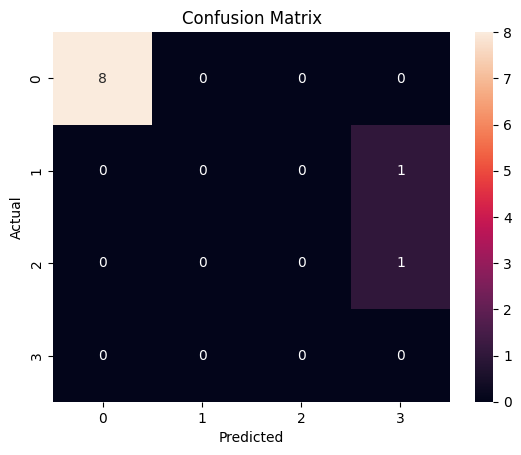

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

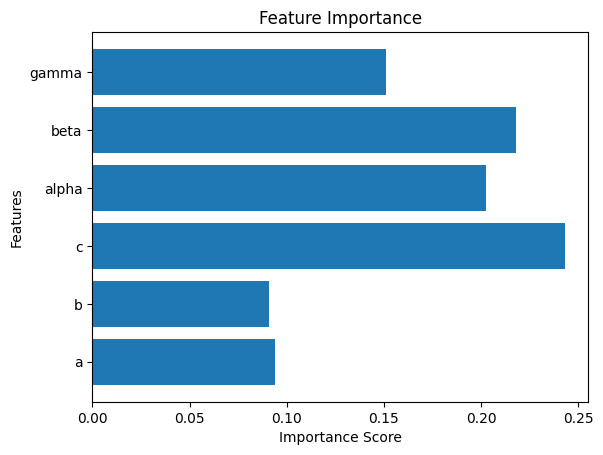

In [ ]:
# Feature Importance
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "crystal_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files

files.download("crystal_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
crystal_demo.launch(share=True, debug=True)

Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://bc865b37126e16f9c2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
